In [1]:
import tensorflow as tf
import sys

print(f"TensorFlow version: {tf.__version__}")
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"SUCCESS: GPU Detected: {gpu_devices}")
else:
    print("WARNING: No GPU detected.")

TensorFlow version: 2.15.0
SUCCESS: GPU Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Install necessary libraries
#!pip install librosa tensorflow pandas scikit-learn matplotlib seaborn

In [3]:
import pandas as pd
import os

file_name = 'data/emotify_dataset/metadata.csv'
if not os.path.exists(file_name):
    print(f"Error: '{file_name}' not found. Please upload the file and run this cell again.")
else:
    print(f"'{file_name}' found! Processing...")
    df = pd.read_csv(file_name)

    # 1. Create the song path column
    def get_song_path(row):
        genre = row[' genre'].strip()
        track_id = row['track id']
        if track_id >= 1 and track_id <= 100:
            return f"{genre}/{track_id}.mp3"
        elif track_id >= 101 and track_id <= 200:
            return f"{genre}/{track_id - 100}.mp3"
        elif track_id >= 201 and track_id <= 300:
            return f"{genre}/{track_id - 200}.mp3"
        elif track_id >= 301 and track_id <= 400:
            return f"{genre}/{track_id - 300}.mp3"
        else:
            return None # Handle cases outside the expected range

    df['songs_path'] = df.apply(get_song_path, axis=1)

    # 2. Identify the emotion columns
    emotion_columns = df.columns[2:11]
    print(f"Using emotion columns: {list(emotion_columns)}")

    # 3. Consolidate labels: Convert to weighted probabilities
    # Calculate the number of listeners for each song
    listener_counts = df.groupby('songs_path').size().reset_index(name='listener_count')

    # Group by songs_path and sum the emotion votes
    emotion_votes = df.groupby('songs_path')[emotion_columns].sum().reset_index()

    # Merge listener counts with emotion votes
    df_aggregated = pd.merge(emotion_votes, listener_counts, on='songs_path')

    # Calculate weighted probabilities
    for col in emotion_columns:
        df_aggregated[col] = df_aggregated.apply(lambda row: row[col] / row['listener_count'], axis=1)

    # Drop the listener_count column as it's no longer needed
    df_consolidated = df_aggregated.drop(columns=['listener_count'])

    # Shuffle the consolidated DataFrame
    df_consolidated = df_consolidated.sample(frac=1).reset_index(drop=True)

    # 4. Save the new cleaned metadata
    output_path = 'data/emotify_dataset/cleaned_metadata_weighted_probabilities.csv'
    df_consolidated.to_csv(output_path, index=False)

    print(f"\n✅ Successfully created '{output_path}'.")
    print("\nPreview of the new metadata:")
    print(df_consolidated.head())

'data/emotify_dataset/metadata.csv' found! Processing...
Using emotion columns: [' amazement', ' solemnity', ' tenderness', ' nostalgia', ' calmness', ' power', ' joyful_activation', ' tension', ' sadness']

✅ Successfully created 'data/emotify_dataset/cleaned_metadata_weighted_probabilities.csv'.

Preview of the new metadata:
          songs_path   amazement   solemnity   tenderness   nostalgia  \
0  electronic/32.mp3    0.272727    0.272727     0.272727    0.090909   
1        rock/84.mp3    0.142857    0.071429     0.285714    0.357143   
2  electronic/29.mp3    0.181818    0.090909     0.000000    0.000000   
3   classical/65.mp3    0.235294    0.058824     0.000000    0.000000   
4         pop/16.mp3    0.073171    0.219512     0.268293    0.268293   

    calmness     power   joyful_activation   tension   sadness  
0   0.363636  0.454545            0.000000  0.272727  0.000000  
1   0.571429  0.000000            0.142857  0.214286  0.000000  
2   0.000000  0.272727            0.2

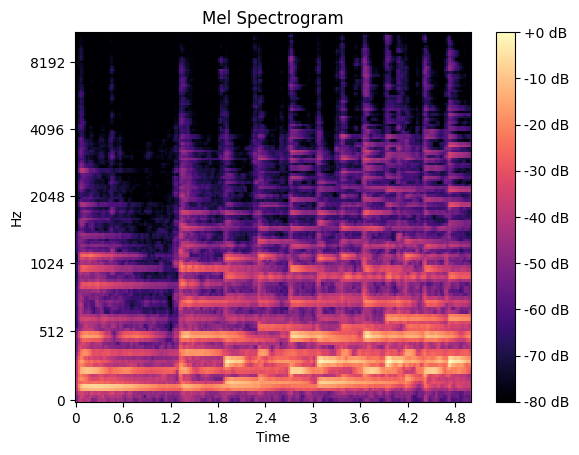

In [4]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# Function to create a Mel Spectrogram
def create_mel_spectrogram(audio_path):
    y, sr = librosa.load(audio_path, duration=5)  # Load audio, use first 45s
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    return log_mel_spec

# Example: Create and display a spectrogram for the first song
first_song_path = 'data/emotify_dataset/' + df.iloc[365]['songs_path']
spectrogram = create_mel_spectrogram(first_song_path)

librosa.display.specshow(spectrogram, sr=22050, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.show()

In [5]:
spectrogram.shape

(128, 216)